In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import PyCO2SYS as co2
from rich import print

In [3]:
# Consider moving the following text to the "Attributes" section rather than "Advanced Attributes".
"""
In addition to the methods listed above, all of the methods usually
available for a `dict` can be used.  Methods such as `keys`, `values` and
`items` will run only over parameters that have already been solved for.
"""
# for internal use properies, use _<name> to "hide" from user

help(co2.CO2System)

Help on class CO2System in module PyCO2SYS.engine:

class CO2System(collections.UserDict)
 |  CO2System(
 |      graph=None,
 |      pd_index=None,
 |      xr_dims=None,
 |      xr_shape=None,
 |      ignored=None,
 |      **kwargs
 |  )
 |
 |  An equilibrium model of the marine carbonate system.
 |
 |  Methods
 |  -------
 |  adjust
 |      Adjust the system to a different temperature and/or pressure.
 |  get_grads
 |      Calculate derivatives of parameters with respect to each other.
 |  keys_all
 |      Return a tuple of all possible results keys, including those that have
 |      not yet been solved for.
 |  plot_graph
 |      Draw graphs showing the relationships between the different parameters.
 |  propagate
 |      Propagate independent uncertainties through the calculations.
 |  solve
 |      Calculate parameter(s) and store them internally.
 |  to_pandas
 |      Return parameters as a pandas `Series` or `DataFrame`.
 |  to_xarray
 |      Return parameters as an xarray `DataA

## Intial testing

Basic testing to see how things work

In [4]:
co2_lab = co2.sys(
    dic=[1900, 2020, 2013, 2100],
    pH=8.1,
    temperature=[20, 20, 20, 20],
    salinity=34,
    opt_k_carbonic=10
)

In [5]:
try: 
    co2_lab.fco2  # calling this first without co2_lab['fco2'] or co2_lab.solve() results in AttributeError - solve not called yet
except AttributeError:
    print("AttributeError: 'CO2Lab' object has no attribute 'fCO2'. Please call co2_lab.solve() first.")

AttributeError: 'CO2Lab' object has no attribute 'fCO2'. Please call co2_lab.solve() first.

In [6]:
co2_lab.get('fCO2') # same with this, returns none since not an attribute of the object yet

In [7]:
co2_lab.solve()

{'dic': Array([1900., 2020., 2013., 2100.], dtype=float64), 'pH': 8.1, 'temperature': Array([20., 20., 20., 20.], dtype=float64), 'salinity': Array(34., dtype=float64, weak_type=True), 'Mg_fraction': 0.0, 'pressure_atmosphere': 1.0, 'pressure': 0.0, 'total_ammonia': 0.0, 'total_phosphate': 0.0, 'total_silicate': 0.0, 'total_sulfide': 0.0, 'total_nitrite': 0.0, 'gas_constant': 83.14462618, 'ionic_strength': array(0.70138223), 'total_fluoride': array(66.37367284), 'total_sulfate': array(27428.70744335), 'Mg': array(53178.04), 'Ca': array(9990.72485225), 'total_borate': array(403.82285714), 'acf_Ca': array([0.1920706, 0.1920706, 0.1920706, 0.1920706]), 'acf_Mg': array([0.20816745, 0.20816745, 0.20816745, 0.20816745]), 'acf_CO3': array([0.04586956, 0.04586956, 0.04586956, 0.04586956]), 'fH': array([0.73066573, 0.73066573, 0.73066573, 0.73066573]), 'pk_aragonite': array([6.19444019, 6.19444019, 6.19444019, 6.19444019]), 'pk_calcite': array([6.3823315, 6.3823315, 6.3823315, 6.3823315]), 'vp_

### Adjusting to insitu conditions

In [8]:
try:
    co2_insitu = (
        co2_lab
        .adjust(temperature=[-1, 14, 15, 30])  # raises TypeError if not a numpy array - those unfamiliar python might struggle here - consider doing a type check
    )
except TypeError as e:
    print(f"Error: {e}")

Error: can only concatenate list (not "float") to list

In [9]:
# ridiculous temperature values to test error handling - and doesn't result in nan. could raise warning?
co2_insitu = (
    co2_lab
    .adjust(temperature=np.array([-1, 25, -10, 100]))  
)

In [10]:
help(co2_insitu.update)  # update is a dictionary method (inherited), but similar to "adjust", could be confusing - potentially just have update as an alias
# but using update in current state doesn't work as one can't use setattr - so better to override update as alias for adjust

Help on method update in module collections.abc:

update(other=(), /, **kwds) method of PyCO2SYS.engine.CO2System instance
    D.update([E, ]**F) -> None.  Update D from mapping/iterable E and F.
    If E present and has a .keys() method, does:     for k in E.keys(): D[k] = E[k]
    If E present and lacks .keys() method, does:     for (k, v) in E: D[k] = v
    In either case, this is followed by: for k, v in F.items(): D[k] = v



In [11]:
co2_insitu = (
    co2_insitu
    .set_uncertainty(temperature=np.array([0.4, 0.5, 0.6, 0.7])) 
    .propagate(uncertainty_into=["pH", "fco2"])  # consider changing default None to "pH" - more explicit for the users
)

# co2_insitu.check_valid(ignore=[]) could also be default


## Testing with Pandas

This is a fantastic feature :) Great that you've incorporated this

In [12]:
df = pd.DataFrame(
    np.c_[
        [2020, 2100, 1900, 2250],
        [2300] * 4,
        [5, 34, -100, 500],
        [34] * 4],
    columns=["dic", "alk", "temperature", "salinity"],
    index=pd.MultiIndex.from_product(((20, 30), (10, 12)), names=("latitude", "longitude"))
)

In [13]:
co2_df = co2.sys(data=df)
co2_df.to_pandas('fco2')

latitude  longitude
20        10           181.556681
          12           914.258171
30        10             0.030076
          12            42.970682
dtype: float64

In [14]:
try:
    co2_df.to_xarray('fco2')  # here, the error isn't clear - says data wasn't provided, but should say xr.Dataset wasn't provided 
except AssertionError as e:
    print(f"Error: {e}")

Error: `data` was not provided as an `xr.Dataset` when creating this `CO2System`.

## Testing with xarray

In [15]:
ds = df.to_xarray()

In [16]:
co2_ds = co2.sys(data=ds)

In [17]:
try:
    co2_ds.to_pandas('fco2')  # here, pandas approach doesn't work - but error info could be more explicit
except ValueError as e:
    print(f"ValueError: {e}")

ValueError: Data must be 1-dimensional, got ndarray of shape (2, 2) instead

## Suggestion for initailisation

Another way to initialise would be to use the .from_<type> methods. This would be quite intuitive. 
Behind the scene, you could simply call co2.sys(data=data, **kwargs)

```python
co2.CO2System.from_dict(kwargs)
co2.CO2System.from_pandas(df)
co2.CO2System.from_xarray(ds)
```

Implimentation would look like this

```python
class CO2System:
    @classmethod
    def from_dict(cls, kwargs):
        return sys(**kwargs)

    @classmethod
    def from_pandas(cls, df):
        data = df.to_dict(orient='list')
        return sys(data=data)

    @classmethod
    def from_xarray(cls, ds):
        data = ds.to_dict()
        return sys(data=data)
```

## Maybe even better

Could even simplify the way the rest of the code is called. 

```python
class CO2System:
    @classmethod
    def from_dict(cls, **kwargs):
        # the usual co2.sys call would go here 
        return co2.sys(**kwargs)
    
    @classmethod
    def from_pandas(cls, df, **kwargs):
        # prepare data for self.from_dict
        data = df.to_dict(orient='list')
        self = cls.from_dict(data=data, **kwargs)
        self.pd_index = df.index
        return self

    @classmethod
    def from_xarray(cls, ds, **kwargs):
        # prepare data for self.from_dict
        data = ds.to_dict()  # hypothetical
        self = cls.from_dict(data=data, **kwargs)
        self.xr_dims = ds.dims  # hypothetical
        self.xr_coords = ds.coords  # hypothetical
        return self
```

## Displaying objects

In [18]:
co2_insitu

{'dic': Array([1900., 2020., 2013., 2100.], dtype=float64), 'salinity': Array(34., dtype=float64, weak_type=True), 'Mg_fraction': 0.0, 'pressure_atmosphere': 1.0, 'pressure': 0.0, 'total_ammonia': 0.0, 'total_phosphate': 0.0, 'total_silicate': 0.0, 'total_sulfide': 0.0, 'total_nitrite': 0.0, 'pH__pre': 8.1, 'temperature__pre': Array([20., 20., 20., 20.], dtype=float64), 'temperature': array([ -1,  25, -10, 100]), 'gas_constant': 83.14462618, 'ionic_strength': array(0.70138223), 'total_fluoride': array(66.37367284), 'total_sulfate': array(27428.70744335), 'Mg__pre': array(53178.04), 'Ca': array(9990.72485225), 'total_borate': array(403.82285714), 'acf_Ca__pre': array([0.1920706, 0.1920706, 0.1920706, 0.1920706]), 'acf_Mg__pre': array([0.20816745, 0.20816745, 0.20816745, 0.20816745]), 'acf_CO3__pre': array([0.04586956, 0.04586956, 0.04586956, 0.04586956]), 'fH__pre': array([0.73066573, 0.73066573, 0.73066573, 0.73066573]), 'pk_aragonite__pre': array([6.19444019, 6.19444019, 6.19444019, 6

In [19]:
if "old_repr" not in locals():
    old_repr = co2.CO2System.__repr__

In [20]:
def generic_repr(self):
    from pprint import pformat

    # Filter out keys ending with '__pre' to avoid showing pre-calculated values - maybe not the best way to do this
    data_dict = {k:v for k, v in self.data.items() if not k.endswith('__pre')}

    dict_repr = pformat(
        data_dict,
        indent=2,
        sort_dicts=False
        )[1:-1]

    return f"{self.__class__.__name__} (\n {dict_repr}\n)"

def new_co2_repr(self):
    from pprint import pformat

    # Filter out keys ending with '__pre' to avoid showing pre-calculated values - maybe not the best way to do this
    filters = "__", "pk_", "factor_"
    data_dict = {k: v for k, v in self.data.items() if not any(f in k for f in filters)}

    # subjective choice of how to order the keys in the output
    custom_order = ['dic', 'alkalinity', 'fCO2', 'pCO2', 'pH', 'temperature', 'salinity', 'pressure']
    custom_order_full = custom_order + [k for k in sorted(data_dict) if k not in custom_order]
    data_dict = {k: data_dict[k] for k in custom_order_full if k in data_dict}

    if self.pd_index is not None:
        input_type = "pd.DataFrame"
    elif self.xr_dims is not None:
        input_type = "xr.Dataset"
    else:
        input_type = "np.ndarray"

    class_name = self.__class__.__name__
    dict_repr = pformat(
        data_dict,
        indent=2,
        sort_dicts=False
        )[1:-1]

    return f"{class_name} [input_type={input_type}] (\n {dict_repr}\n)"

# very ugly way to override the __repr__ - do this in the functions 
co2_insitu.__class__.__repr__ = new_co2_repr
# co2_insitu.uncertainty.__class__.__repr__ = generic_repr
co2_insitu.grads.__class__.__repr__ = generic_repr
# co2_insitu.__class__.__repr__ = old_repr

In [21]:
co2_insitu

CO2System [input_type=np.ndarray] (
  'dic': Array([1900., 2020., 2013., 2100.], dtype=float64),
  'alkalinity': array([2169.05016781, 2300.25442273, 2292.60084119, 2387.723926  ]),
  'fCO2': array([ 129.51768288,  424.33595695,   88.13688902, 5608.18624376]),
  'pCO2': array([ 130.09710587,  425.69373242,   88.58355034, 5615.20260064]),
  'pH': array([8.43530314, 8.02432316, 8.59280969, 7.00160376]),
  'temperature': array([ -1,  25, -10, 100]),
  'salinity': Array(34., dtype=float64, weak_type=True),
  'pressure': 0.0,
  'BOH3': array([306.31222188, 319.55349358, 302.57532812, 336.79295859]),
  'BOH4': array([ 97.51063527,  84.26936356, 101.24752902,  67.02989856]),
  'CO2': array([ 8.5207224 , 12.11052513,  8.51470506, 67.95811782]),
  'CO3': array([178.87803744, 201.85081732, 186.28083396, 207.06406447]),
  'Ca': array(9990.72485225),
  'F': array([66.37361523, 66.37346149, 66.37363894, 66.37044217]),
  'H': array([3.67026027e-09, 9.45533320e-09, 2.55382017e-09, 9.96314007e-08]),
 

In [22]:
co2_insitu.uncertainty

Uncertainties (
  'pH': Array([0.00674909, 0.00750551, 0.01078642, 0.0082913 ], dtype=float64),
  'fCO2': Array([  2.44324939,   8.52122426,   2.68896966, 104.60185957], dtype=float64)
)

In [23]:
co2_insitu.grads  # shows ShortcutDotDict - maybe rename ShortcutDotDict to DotDict if you choose to adapt this

ShortcutDotDict (
  'pH': ShortcutDotDict (
  'temperature': Array([-0.01687273, -0.01501102, -0.01797737, -0.01184471], dtype=float64)
),
  'fCO2': ShortcutDotDict (
  'temperature': Array([  6.10812347,  17.04244853,   4.48161609, 149.43122796], dtype=float64)
)
)

In [24]:
print(co2_insitu)  # using rich.print

CO2System [input_type=np.ndarray] (
  'dic': Array([1900., 2020., 2013., 2100.], dtype=float64),
  'alkalinity': array([2169.05016781, 2300.25442273, 2292.60084119, 2387.723926  ]),
  'fCO2': array([ 129.51768288,  424.33595695,   88.13688902, 5608.18624376]),
  'pCO2': array([ 130.09710587,  425.69373242,   88.58355034, 5615.20260064]),
  'pH': array([8.43530314, 8.02432316, 8.59280969, 7.00160376]),
  'temperature': array([ -1,  25, -10, 100]),
  'salinity': Array(34., dtype=float64, weak_type=True),
  'pressure': 0.0,
  'BOH3': array([306.31222188, 319.55349358, 302.57532812, 336.79295859]),
  'BOH4': array([ 97.51063527,  84.26936356, 101.24752902,  67.02989856]),
  'CO2': array([ 8.5207224 , 12.11052513,  8.51470506, 67.95811782]),
  'CO3': array([178.87803744, 201.85081732, 186.28083396, 207.06406447]),
  'Ca': array(9990.72485225),
  'F': array([66.37361523, 66.37346149, 66.37363894, 66.37044217]),
  'H': array([3.67026027e-09, 9.45533320e-09, 2.55382017e-09, 9.96314007e-08]),
  'H2PO4': array([0., 0., 0., 0.]),
  'H2S': array([0., 0., 0., 0.]),
  'H3PO4': array([0., 0., 0., 0.]),
  'H3SiO4': array([0., 0., 0., 0.]),
  'H4SiO4': array([0., 0., 0., 0.]),
  'HCO3': array([1712.60124016, 1806.03865755, 1818.20446098, 1824.97781771]),
  'HF': array([5.76079728e-05, 2.11349517e-04, 3.39025361e-05, 3.23066658e-03]),
  'HNO2': array([0., 0., 0., 0.]),
  'HPO4': array([0., 0., 0., 0.]),
  'HS': array([0., 0., 0., 0.]),
  'HSO4': array([0.00031471, 0.00205943, 0.00014223, 0.06092883]),
  'H_free': array([0.00335555, 0.0073959 , 0.00241159, 0.03870243]),
  'Mg': array(53178.04),
  'Mg_fraction': 0.0,
  'NH3': array([0., 0., 0., 0.]),
  'NH4': array([0., 0., 0., 0.]),
  'NO2': array([0., 0., 0., 0.]),
  'OH': array([ 1.18594538,  6.25443366,  0.589771  , 81.69094274]),
  'PO4': array([0., 0., 0., 0.]),
  'Q_isocap': array([1.20909946, 1.21570401, 1.20495867, 1.2464491 ]),
  'Q_isocap_approx': array([1.23072228, 1.24921282, 1.22571537, 1.26079295]),
  'SO4': array([27428.70712864, 27428.70538392, 27428.70730112, 27428.64651452]),
  'acf_CO3': array([0.05304644, 0.04416143, 0.05612359, 0.01856914]),
  'acf_Ca': array([0.19175481, 0.18981291,        nan, 0.14945658]),
  'acf_Mg': array([0.22324871, 0.20437349, 0.22919538, 0.14180895]),
  'beta_alkalinity': array([-0.00024728, -0.00026909, -0.00025555, -0.00040351]),
  'beta_dic': array([0.00022693, 0.00024598, 0.00023482, 0.00037844]),
  'fH': array([0.80922883, 0.71196024, 0.84289874, 0.43137773]),
  'free_to_sws_1atm': array([-0.04569669, -0.11628623, -0.03061499, -0.42451766]),
  'fugacity_factor': array([0.99554623, 0.99681044, 0.99495774, 0.99875047]),
  'gamma_alkalinity': array([-0.00022693, -0.00024598, -0.00023482, -0.00037844]),
  'gamma_dic': array([0.00018769, 0.00020234, 0.00019487, 0.00030361]),
  'gas_constant': 83.14462618,
  'ionic_strength': array(0.70138223),
  'nbs_to_sws': array([-0.09192865, -0.14754426, -0.0742246 , -0.36514227]),
  'omega_alkalinity': array([0.00027163, 0.00029698, 0.00028031, 0.00043213]),
  'omega_dic': array([-0.00028693, -0.00031363, -0.00029535, -0.00050221]),
  'opt_to_free': array([0.03893299, 0.10668557, 0.02488757, 0.41065798]),
  'opt_to_nbs': array([0.08516495, 0.13794361, 0.06849717, 0.3512826 ]),
  'opt_to_sws': array([-0.0067637 , -0.00960066, -0.00572743, -0.01385968]),
  'pH_free': array([8.47423613, 8.13100873, 8.61769725, 7.41226174]),
  'pH_nbs': array([8.52046809, 8.16226677, 8.66130686, 7.35288636]),
  'pH_sws': array([8.42853944, 8.01472251, 8.58708226, 6.98774409]),
  'pH_total': array([8.43530314, 8.02432316, 8.59280969, 7.00160376]),
  'pkt_Mg_calcite_1atm': array([8.1933775 , 8.29393478, 8.18026638, 9.0806422 ]),
  'pkt_Mg_calcite_25C_1atm': 8.29393478,
  'pressure_atmosphere': 1.0,
  'psi': array([0.65412364, 0.64513729, 0.65980797, 0.6045581 ]),
  'revelle_factor': array([10.12326321,  9.98334821, 10.3297271 ,  6.91671788]),
  'saturation_Mg_calcite': array([2.83748789, 3.32606818,        nan, 6.91275024]),
  'satur

# Large array testing

In [25]:
%%time
dic_flat = np.linspace(1900, 2200, 10_000)
alk_flat = np.linspace(2100, 2400, 10_000)
dic, alk = np.meshgrid(dic_flat, alk_flat) 

co2_big = co2.sys(
    dic=dic,
    alk=alk,
    temperature=25,
    salinity=34.5,
    opt_k_carbonic=10
).solve(parameters='fco2')

CPU times: user 44.6 s, sys: 21.1 s, total: 1min 5s
Wall time: 21.2 s


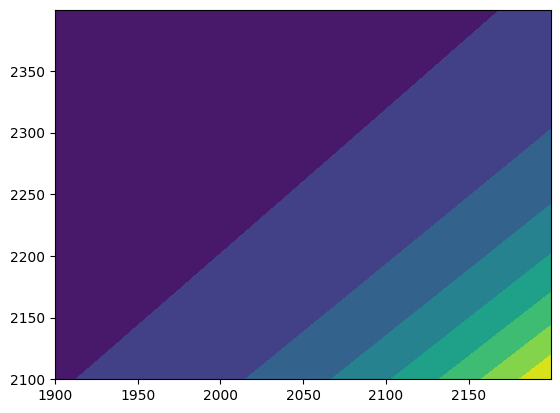

In [26]:
plt.contourf(dic_flat[::10], alk_flat[::10], co2_big.fco2[::10, ::10])